# Trabalho prático 2
Implementação e análise do algoritmo K-Means usando a base Iris

## Introdução

Este notebook apresenta uma aplicação de aprendizado não supervisionado com o algoritmo K-Means. O objetivo é investigar como diferentes valores de K formam agrupamentos e como a padronização dos atributos influencia o resultado.

A base Iris possui 150 amostras e quatro atributos: comprimento e largura da sépala, e comprimento e largura da pétala. Embora a base também forneça as espécies verdadeiras, esses rótulos não serão usados pelo K-Means. Eles serão consultados somente ao final, para uma comparação posterior dos agrupamentos encontrados.

No K-Means, cada amostra é atribuída ao centróide mais próximo e os centróides são recalculados até que as atribuições se estabilizem. Como essa decisão depende de distâncias, a representação dos atributos é importante: uma variável com valores numericamente maiores ou mais dispersos pode influenciar mais a distância, mesmo que não seja mais relevante para o fenômeno estudado.

A qualidade dos agrupamentos será analisada por três perspectivas. A inércia, ou WCSS, mede o quanto as amostras ficam próximas dos centróides. O Método do Cotovelo observa a redução da inércia para diferentes valores de K e procura um ponto em que novos clusters passam a trazer ganhos menores. Já o Silhouette Score combina coesão e separação: compara a distância de uma amostra ao próprio grupo com a distância ao grupo vizinho mais próximo. Valores próximos de 1 indicam agrupamentos bem separados, valores próximos de 0 indicam sobreposição e valores negativos sugerem possíveis atribuições inadequadas.

A análise também usa PCA para representar quatro dimensões em um gráfico de duas dimensões. Essa redução serve apenas à visualização; o K-Means continua sendo treinado com os quatro atributos padronizados.

## Integrantes

- Anderson Fernandes Barbosa
- João Pedro Brites

## Objetivos

- Aplicar o K-Means a uma base de dados sem usar rótulos como entrada;
- testar diferentes quantidades de clusters;
- avaliar os agrupamentos com inércia/WCSS e Silhouette Score;
- analisar o efeito da padronização;
- justificar a escolha dos atributos e de K;
- visualizar e comparar os clusters, discutindo as limitações do método.

## Fundamentação

O K-Means divide as observações em K grupos. Em cada iteração, cada amostra é associada ao centróide mais próximo e, em seguida, os centróides são recalculados como a média das amostras atribuídas. O processo continua até a estabilização ou até atingir o número máximo de iterações.

A inércia, também chamada de WCSS (Within-Cluster Sum of Squares), é a soma das distâncias quadráticas entre cada amostra e o centróide do seu cluster:

$$WCSS = \sum_{j=1}^{K} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$

Ela mede a compactação interna: quanto menor, mais próximas estão as amostras de seus centróides. Porém, a inércia sempre tende a diminuir quando K aumenta. No limite, com um cluster por amostra, ela chega a zero. Portanto, não se escolhe o maior K apenas por ter a menor inércia.

O Método do Cotovelo calcula a inércia para vários valores de K e procura uma mudança visível na inclinação da curva. Antes do cotovelo, adicionar um cluster costuma reduzir bastante o WCSS; depois dele, a redução é menor e pode representar apenas uma divisão artificial dos grupos. O cotovelo é, portanto, um critério de compromisso entre compactação e simplicidade, e nem sempre aparece como um ponto perfeitamente nítido.

O Silhouette Score avalia cada amostra comparando duas distâncias: $a$, a distância média até as amostras do próprio cluster, e $b$, a menor distância média até outro cluster. Para uma amostra, o valor é:

$$s = \frac{b-a}{\max(a,b)}$$

A média desses valores resume a qualidade do agrupamento. Valores próximos de 1 indicam grupos compactos e bem separados; valores próximos de 0 indicam amostras na fronteira entre grupos; valores negativos sugerem que algumas amostras podem estar mais próximas de outro cluster. Diferentemente da inércia, essa métrica considera também a separação entre grupos, mas ainda deve ser interpretada junto com o objetivo e o conhecimento sobre os dados.

A padronização será avaliada porque os atributos estão em escalas e dispersões diferentes. Com `StandardScaler`, cada atributo passa a ter média aproximadamente zero e desvio padrão aproximadamente um, evitando que uma variável domine as distâncias por motivos puramente numéricos. Por exemplo, uma diferença de 1 cm em comprimento de sépala e uma diferença de 1 cm em comprimento de pétala têm a mesma unidade, mas a importância relativa dessa diferença pode ser diferente quando consideramos a dispersão observada na base. Após a padronização, a distância usa diferenças relativas ao comportamento de cada atributo: uma diferença de um desvio padrão tem peso comparável em qualquer variável.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Carregamento e exploração da base

In [2]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()
nomes_atributos = X.columns.tolist()
nomes_especies = iris.target_names.tolist()

print(f'Quantidade de amostras: {X.shape[0]}')
print(f'Quantidade de atributos: {X.shape[1]}')
print('Atributos utilizados pelo K-Means:', nomes_atributos)
print('Valores ausentes:', X.isna().sum().sum())

display(X.head())
display(X.describe().round(2))

Quantidade de amostras: 150
Quantidade de atributos: 4
Atributos utilizados pelo K-Means: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Valores ausentes: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


Os quatro atributos serão usados como entrada do algoritmo. A variável `y`, que contém as espécies, permanece separada e não participa do treinamento. Isso preserva o caráter não supervisionado da atividade.

## 2. Efeito da padronização

In [3]:
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)
X_padronizado = pd.DataFrame(X_padronizado, columns=nomes_atributos)

comparacao_escala = pd.DataFrame({
    'media_original': X.mean(),
    'desvio_original': X.std(),
    'media_padronizada': X_padronizado.mean(),
    'desvio_padronizado': X_padronizado.std()
})
display(comparacao_escala.round(3))

exemplo_distancia = pd.DataFrame({
    'atributo': nomes_atributos,
    'valor_amostra_A': X.iloc[0].values,
    'valor_amostra_B': X.iloc[1].values,
    'diferenca_original': (X.iloc[0] - X.iloc[1]).abs().values,
    'diferenca_padronizada': (X_padronizado.iloc[0] - X_padronizado.iloc[1]).abs().values
})
display(exemplo_distancia.round(3))

,media_original,desvio_original,media_padronizada,desvio_padronizado
sepal length (cm),5.843,0.828,-0.0,1.003
sepal width (cm),3.057,0.436,-0.0,1.003
petal length (cm),3.758,1.765,-0.0,1.003
petal width (cm),1.199,0.762,-0.0,1.003


,atributo,valor_amostra_A,valor_amostra_B,diferenca_original,diferenca_padronizada
0,sepal length (cm),5.1,4.9,0.2,0.242
1,sepal width (cm),3.5,3.0,0.5,1.151
2,petal length (cm),1.4,1.4,0.0,0.000
3,petal width (cm),0.2,0.2,0.0,0.000


A padronização torna as escalas comparáveis, mas não apaga a informação dos atributos: ela apenas transforma cada variável para uma unidade baseada em seu próprio desvio padrão. O exemplo acima mostra que uma diferença bruta de 0,5 cm na largura da sépala equivale a aproximadamente 1,15 desvios padrão, enquanto uma diferença de 0,2 cm no comprimento da sépala equivale a apenas 0,24 desvios padrão. Assim, o K-Means passa a considerar o afastamento relativo à variabilidade de cada medida, e não apenas os números em centímetros.

A diferença entre os resultados com e sem padronização será medida empiricamente pelas curvas de inércia, pelos Silhouette Scores e pela composição dos clusters. Essa comparação é importante porque a padronização é uma escolha de modelagem: ela é apropriada quando queremos dar peso comparável às variáveis, mas pode não ser desejável se a escala original tiver um significado de peso intencional.

## 3. Método do Cotovelo e Silhouette Score

In [4]:
valores_k = range(2, 9)
resultados = []

for escala, dados in [('Sem padronização', X), ('Padronizado', X_padronizado)]:
    for k in valores_k:
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        clusters = modelo.fit_predict(dados)
        resultados.append({
            'escala': escala,
            'K': k,
            'inercia_WCSS': modelo.inertia_,
            'silhouette_score': silhouette_score(dados, clusters)
        })

resultados = pd.DataFrame(resultados)
display(resultados.round(4))

,escala,K,inercia_WCSS,silhouette_score
0,Sem padronização,2,152.3480,0.6810
1,Sem padronização,3,78.8514,0.5528
2,Sem padronização,4,57.2285,0.4981
3,Sem padronização,5,46.4612,0.4912
4,Sem padronização,6,39.0400,0.3648
5,Sem padronização,7,34.3058,0.3543
6,Sem padronização,8,30.1324,0.3487
7,Padronizado,2,222.3617,0.5818
8,Padronizado,3,139.8205,0.4599
9,Padronizado,4,114.0925,0.3869


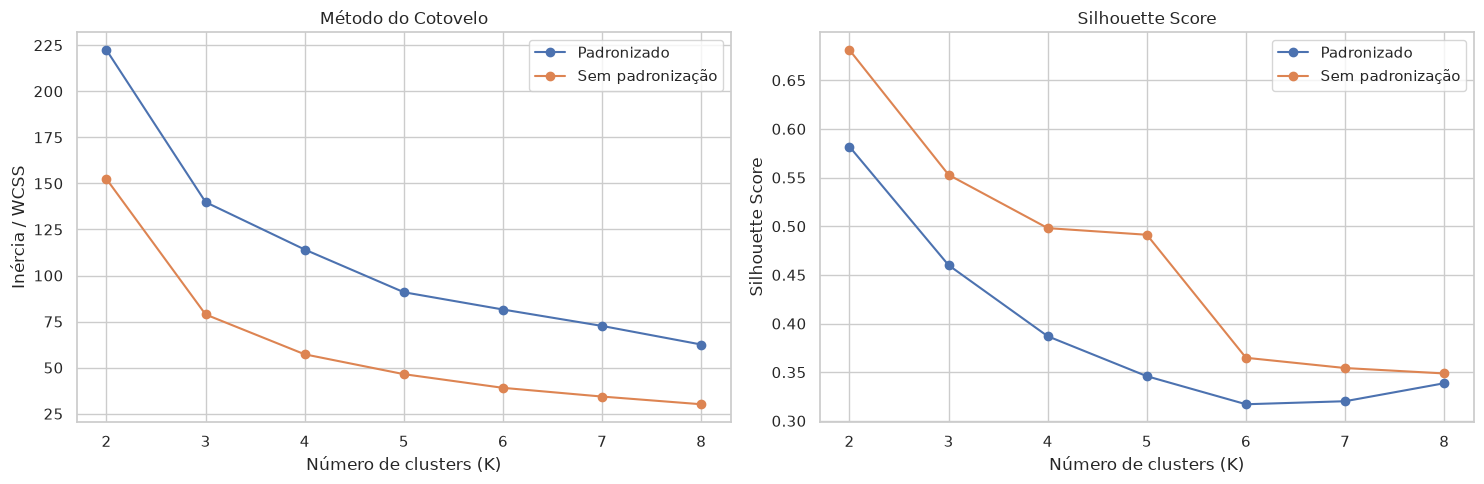

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

for escala, grupo in resultados.groupby('escala'):
    eixos[0].plot(grupo['K'], grupo['inercia_WCSS'], marker='o', label=escala)
    eixos[1].plot(grupo['K'], grupo['silhouette_score'], marker='o', label=escala)

eixos[0].set_title('Método do Cotovelo')
eixos[0].set_xlabel('Número de clusters (K)')
eixos[0].set_ylabel('Inércia / WCSS')
eixos[0].set_xticks(list(valores_k))
eixos[0].legend()

eixos[1].set_title('Silhouette Score')
eixos[1].set_xlabel('Número de clusters (K)')
eixos[1].set_ylabel('Silhouette Score')
eixos[1].set_xticks(list(valores_k))
eixos[1].legend()

plt.tight_layout()
plt.show()

### Interpretação das métricas

A inércia diminui conforme K cresce, portanto não deve ser interpretada isoladamente. O ponto de interesse é a mudança na inclinação da curva, quando adicionar novos clusters passa a trazer ganhos menores. Uma queda grande de K=2 para K=3, seguida por quedas menores, sugere que K=3 captura uma estrutura importante sem aumentar demais a complexidade.

Neste experimento, o maior Silhouette Score foi obtido com K=2, tanto sem padronização quanto com padronização. Isso indica que duas regiões apresentam maior separação geométrica, provavelmente porque uma das espécies da Iris é mais distinta e as outras duas possuem maior sobreposição. Esse resultado não contradiz o uso de K=3: ele mostra que compactação e separação geométrica máximas não são exatamente o mesmo objetivo que representar a estrutura conhecida da base.

A escolha final de K=3 é justificada por um compromisso entre três evidências. Primeiro, a região do cotovelo indica que dividir os dados em três grupos ainda traz ganho relevante de compactação. Segundo, K=3 permite investigar uma estrutura compatível com as três espécies conhecidas, embora os rótulos não tenham sido usados no treinamento. Terceiro, a visualização por PCA permite verificar se o terceiro grupo aparece como uma subdivisão interpretável, em vez de ser apenas uma divisão artificial.

Assim, K=3 é uma escolha interpretável e adequada ao objetivo didático de relacionar os agrupamentos às características da Iris, mas não é a única escolha defensável. Se o objetivo fosse exclusivamente maximizar o Silhouette Score e obter a solução mais simples, K=2 seria uma alternativa forte. A decisão deve considerar simultaneamente as curvas, a finalidade da análise e a visualização, e não apenas o valor de uma métrica.

## 4. Agrupamento final com K=3

In [6]:
K_ESCOLHIDO = 3
modelo_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
clusters_finais = modelo_final.fit_predict(X_padronizado)

print(f'K escolhido: {K_ESCOLHIDO}')
print(f'Inércia/WCSS: {modelo_final.inertia_:.4f}')
print(f'Silhouette Score: {silhouette_score(X_padronizado, clusters_finais):.4f}')

centroides_padronizados = pd.DataFrame(modelo_final.cluster_centers_, columns=nomes_atributos)
centroides_originais = pd.DataFrame(
    scaler.inverse_transform(modelo_final.cluster_centers_),
    columns=nomes_atributos
)
centroides_originais.index.name = 'cluster'
print('Centróides convertidos para a escala original:')
display(centroides_originais.round(2))

K escolhido: 3
Inércia/WCSS: 139.8205
Silhouette Score: 0.4599
Centróides convertidos para a escala original:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


## 5. Visualização dos agrupamentos com PCA

Cargas dos atributos nos componentes principais:


,PCA 1,PCA 2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


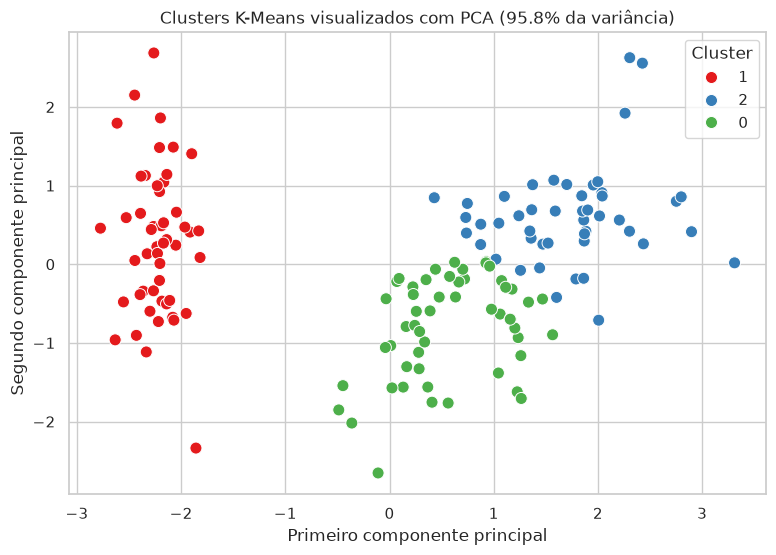

Variância explicada pelos dois componentes: 95.81%


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_padronizado)
variancia_explicada = pca.explained_variance_ratio_.sum()

cargas_pca = pd.DataFrame(
    pca.components_.T,
    index=nomes_atributos,
    columns=['PCA 1', 'PCA 2']
)
print('Cargas dos atributos nos componentes principais:')
display(cargas_pca.round(3))

visualizacao = pd.DataFrame({
    'PCA 1': X_pca[:, 0],
    'PCA 2': X_pca[:, 1],
    'Cluster': clusters_finais.astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=visualizacao, x='PCA 1', y='PCA 2', hue='Cluster', palette='Set1', s=75)
plt.title(f'Clusters K-Means visualizados com PCA ({variancia_explicada:.1%} da variância)')
plt.xlabel('Primeiro componente principal')
plt.ylabel('Segundo componente principal')
plt.legend(title='Cluster')
plt.show()

print(f'Variância explicada pelos dois componentes: {variancia_explicada:.2%}')

O PCA reduz os quatro atributos para duas componentes apenas para facilitar a visualização. A escolha de manter os quatro atributos no treinamento é intencional: sépala e pétala descrevem aspectos complementares do formato da flor, e comprimento e largura de pétala apresentam forte sinergia para distinguir flores menores de flores maiores. Ao mesmo tempo, usar apenas pétalas poderia ignorar informação estrutural da sépala.

O PCA aproveita essa relação entre variáveis correlacionadas para construir eixos que concentram a maior variância possível. Por isso, os dois primeiros componentes costumam separar bem os grupos, mas não preservam toda a informação. O K-Means foi executado nos quatro atributos padronizados; portanto, o gráfico não substitui o treinamento nem representa sozinho todas as dimensões dos dados.

## 6. Comparação posterior com os rótulos conhecidos

A comparação com os rótulos verdadeiros não participa do treinamento e não transforma o K-Means em um classificador. Ela serve como uma referência didática: permite observar se a estrutura descoberta sem supervisão se aproxima das espécies conhecidas.

A tabela cruza cada espécie com os clusters encontrados. Como os números dos clusters são arbitrários, não é adequado comparar diretamente o número do cluster com o número da classe. O ARI é usado apenas como medida auxiliar de concordância, pois considera a organização dos pares de amostras e não depende dos nomes numéricos atribuídos aos clusters.

Além da tabela, o gráfico apresenta a mesma projeção PCA duas vezes: à esquerda, as cores representam os clusters produzidos pelo K-Means; à direita, as cores representam as espécies reais. Essa comparação visual ajuda a identificar quais regiões foram recuperadas pelo agrupamento e onde existe sobreposição. A imagem abaixo é uma referência visual da base Iris, enquanto a análise quantitativa continua baseada nos quatro atributos da tabela.

![Exemplo visual das flores da base Iris](../Trabalho_pratico_1/imgs/iris_flowers.png)

Cluster encontrado,0,1,2
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


Adjusted Rand Index (ARI), usado apenas para análise posterior: 0.6201


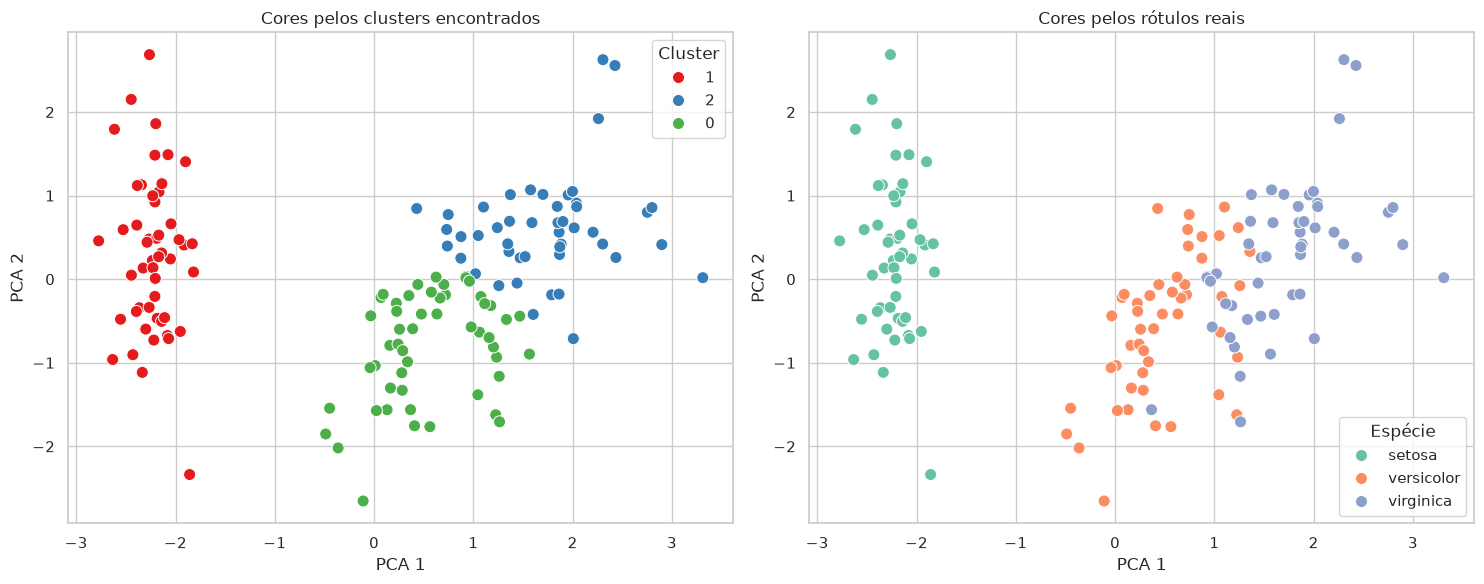

In [8]:
comparacao = pd.crosstab(
    pd.Series(y, name='Espécie real'),
    pd.Series(clusters_finais, name='Cluster encontrado')
)
comparacao.index = nomes_especies
display(comparacao)

ari = adjusted_rand_score(y, clusters_finais)
print(f'Adjusted Rand Index (ARI), usado apenas para análise posterior: {ari:.4f}')

visualizacao['Espécie real'] = y.map(dict(enumerate(nomes_especies)))
fig, eixos = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=visualizacao, x='PCA 1', y='PCA 2', hue='Cluster',
    palette='Set1', s=75, ax=eixos[0]
)
eixos[0].set_title('Cores pelos clusters encontrados')
eixos[0].legend(title='Cluster')

sns.scatterplot(
    data=visualizacao, x='PCA 1', y='PCA 2', hue='Espécie real',
    palette='Set2', s=75, ax=eixos[1]
)
eixos[1].set_title('Cores pelos rótulos reais')
eixos[1].legend(title='Espécie')

plt.tight_layout()
plt.show()

A tabela cruza os clusters com as espécies verdadeiras, mas essa informação não foi fornecida ao algoritmo. Como os números dos clusters são arbitrários, não é adequado comparar diretamente o número do cluster com o número da classe. O ARI é usado apenas como medida auxiliar de concordância após o agrupamento.

## 7. Análise e discussão

### Influência de K e qualidade dos agrupamentos

Aumentar K sempre reduz a inércia, pois cada grupo passa a representar uma quantidade menor de pontos. Porém, K muito alto pode dividir grupos naturais em subgrupos artificiais. O cotovelo indica um compromisso entre compactação e simplicidade, enquanto o Silhouette Score favorece grupos simultaneamente compactos e separados.

Os resultados mostram que K=2 produz o maior Silhouette Score, mas K=3 ainda oferece uma solução coerente para o objetivo didático: a primeira divisão separa claramente o grupo de flores menores, enquanto a terceira divisão permite distinguir duas regiões de flores maiores. O custo dessa escolha aparece no silhouette menor, causado pela sobreposição entre os grupos associados a versicolor e virginica.

### Efeito da padronização

Como o K-Means usa distâncias, atributos com maior dispersão podem influenciar mais o resultado. A padronização coloca todas as variáveis em uma escala comparável e faz com que uma diferença seja interpretada em relação ao desvio padrão da variável. Neste experimento, a escolha final usa os dados padronizados, e os centróides são convertidos novamente para a escala original para facilitar a interpretação.

### Atributos e projeção PCA

Os quatro atributos foram mantidos porque descrevem dimensões complementares da flor. As medidas de pétala têm forte relação entre si e são especialmente informativas para distinguir flores menores de flores maiores; as medidas de sépala acrescentam informação estrutural que poderia ser perdida se usássemos apenas as pétalas. As cargas exibidas na etapa de PCA ajudam a visualizar essa contribuição conjunta.

O PCA concentra 95,81% da variância nos dois primeiros componentes, permitindo uma representação bidimensional bastante informativa. Ainda assim, os eixos são combinações dos quatro atributos e não equivalem a selecionar apenas duas variáveis. A projeção facilita a leitura dos grupos, mas o treinamento do K-Means continua ocorrendo no espaço original padronizado de quatro dimensões.

### Características dos grupos

Os centróides na escala original indicam três perfis: um grupo com pétalas pequenas (comprimento médio 1,46 cm e largura média 0,25 cm), um grupo intermediário (4,37 cm e 1,41 cm) e um grupo com pétalas maiores (5,51 cm e 1,97 cm). A tabela de comparação mostra que o primeiro perfil reúne as 50 amostras de setosa, enquanto os dois perfis de pétalas maiores dividem versicolor e virginica com alguma mistura. Essa mistura é esperada, pois essas espécies apresentam características morfológicas parcialmente sobrepostas.

### Limitações do K-Means

O algoritmo exige que K seja informado, é sensível à inicialização e pode ser afetado por outliers e pela escala dos atributos. Além disso, pressupõe grupos aproximadamente compactos e baseados em distância euclidiana. Ele também não garante que os grupos encontrados correspondam exatamente às classes verdadeiras. O ARI e a imagem com os rótulos reais são referências posteriores para estudo, não dados usados na construção dos clusters.

## Conclusão

O experimento mostrou como o K-Means pode encontrar agrupamentos sem receber as espécies da Iris como entrada. A análise conjunta da inércia, do Método do Cotovelo, do Silhouette Score, das cargas do PCA e da visualização fundamenta a escolha de K=3 para este estudo. Essa escolha não maximiza isoladamente o silhouette, mas oferece um compromisso entre compactação, interpretação e a investigação das três estruturas conhecidas da base.

A padronização foi importante para que as quatro medidas contribuíssem de maneira comparável nas distâncias. A comparação posterior mostrou que o grupo de pétalas pequenas é recuperado com clareza, enquanto versicolor e virginica possuem sobreposição. Portanto, a análise visual e o ARI ajudam a interpretar o resultado, mas não mudam o caráter não supervisionado do treinamento.

## Vídeo de apresentação

Inserir aqui o link do vídeo antes da entrega: `COLE_AQUI_O_LINK_DO_VIDEO`